In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pickle

# Neural x Behavioral Error Correlation

In [27]:
# Replace the single-region CSV load with the all-regions file
df_behavior = pd.read_csv('/home/aarghavan/aslan/data/behavior_all.csv')
df_neural = pd.read_csv('/home/aarghavan/aslan/delsac-neural-decoding/results/archive/errors_angular.csv')

df_neural_target = df_neural[df_neural['angle_name'] == 'targetAngle'].copy()
df_neural_target['time'] = df_neural_target['time'].round(3)
df_neural_target['original_session'] = (
    df_neural_target['original_session']
    .str.strip("[]'")
    .replace('', np.nan)
    .astype(float)
    .astype('Int64')  # nullable integer, tolerates NaN
)
df_neural_target['error_deg'] = np.degrees(df_neural_target['error'])

# Align dtypes for merge keys
# Clean behavior session_id to numeric
df_behavior['session_id'] = (
    df_behavior['session_id']
    .astype(str)
    .str.strip("[]' ")
    .replace('', np.nan)
    .astype(float)
    .astype('Int64')
)
df_behavior['trial_id'] = pd.to_numeric(df_behavior['trial_id'], errors='coerce').astype('Int64')

# Also ensure neural trial key matches
df_neural_target['original_trial'] = pd.to_numeric(df_neural_target['original_trial'], errors='coerce').astype('Int64')

# Merge neural and behavior data
df_merged = df_neural_target.merge(
    df_behavior[['session_id', 'trial_id', 'err']],
    left_on=['original_session', 'original_trial'],
    right_on=['session_id', 'trial_id'],
    how='left'
)

/tmp/ipykernel_2807464/286212420.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_neural = pd.read_csv('/home/aarghavan/aslan/delsac-neural-decoding/results/archive/errors_angular.csv')


In [28]:
df_neural_target

,area,session,original_session,original_trial,angle_name,trial,time_idx,time,error,error_deg
0,PFC,0,100725,3,targetAngle,0,0,-2.5,0.778638,44.612644
1,PFC,0,100725,3,targetAngle,0,1,-2.4,1.621403,92.899556
2,PFC,0,100725,3,targetAngle,0,2,-2.3,0.204964,11.743555
3,PFC,0,100725,3,targetAngle,0,3,-2.2,1.900231,108.875226
4,PFC,0,100725,3,targetAngle,0,4,-2.1,2.362186,135.343275
...,...,...,...,...,...,...,...,...,...,...
7503084,V4,62,<NA>,1415,targetAngle,82,54,2.9,1.848414,105.906315
7503085,V4,62,<NA>,1415,targetAngle,82,55,3.0,2.675518,153.295874
7503086,V4,62,<NA>,1415,targetAngle,82,56,3.1,2.721201,155.913352
7503087,V4,62,<NA>,1415,targetAngle,82,57,3.2,-3.135590,-179.656048


In [29]:
df_merged

,area,session,original_session,original_trial,angle_name,trial,time_idx,time,error,error_deg,session_id,trial_id,err
0,PFC,0,100725,3,targetAngle,0,0,-2.5,0.778638,44.612644,100725,3,4.307453
1,PFC,0,100725,3,targetAngle,0,1,-2.4,1.621403,92.899556,100725,3,4.307453
2,PFC,0,100725,3,targetAngle,0,2,-2.3,0.204964,11.743555,100725,3,4.307453
3,PFC,0,100725,3,targetAngle,0,3,-2.2,1.900231,108.875226,100725,3,4.307453
4,PFC,0,100725,3,targetAngle,0,4,-2.1,2.362186,135.343275,100725,3,4.307453
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879440,V4,62,<NA>,1415,targetAngle,82,54,2.9,1.848414,105.906315,<NA>,<NA>,NaN
1879441,V4,62,<NA>,1415,targetAngle,82,55,3.0,2.675518,153.295874,<NA>,<NA>,NaN
1879442,V4,62,<NA>,1415,targetAngle,82,56,3.1,2.721201,155.913352,<NA>,<NA>,NaN
1879443,V4,62,<NA>,1415,targetAngle,82,57,3.2,-3.135590,-179.656048,<NA>,<NA>,NaN


In [30]:
print(len(df_merged[(df_merged['area'] == 'PFC') & (df_merged['original_session'] == 100726) & (df_merged['original_trial'] == 6)]))
# df_merged[(df_merged['area'] == 'PFC') & (df_merged['original_session'] == 100726) & (df_merged['original_trial'] == 6)]

59


In [31]:
def circ_corr(alpha, beta):
    """
    Circular correlation coefficient between two angle arrays (radians).
    """
    sin_a = np.sin(alpha - np.mean(alpha))
    sin_b = np.sin(beta - np.mean(beta))
    num = np.sum(sin_a * sin_b)
    den = np.sqrt(np.sum(sin_a**2) * np.sum(sin_b**2))
    return num / den if den != 0 else np.nan

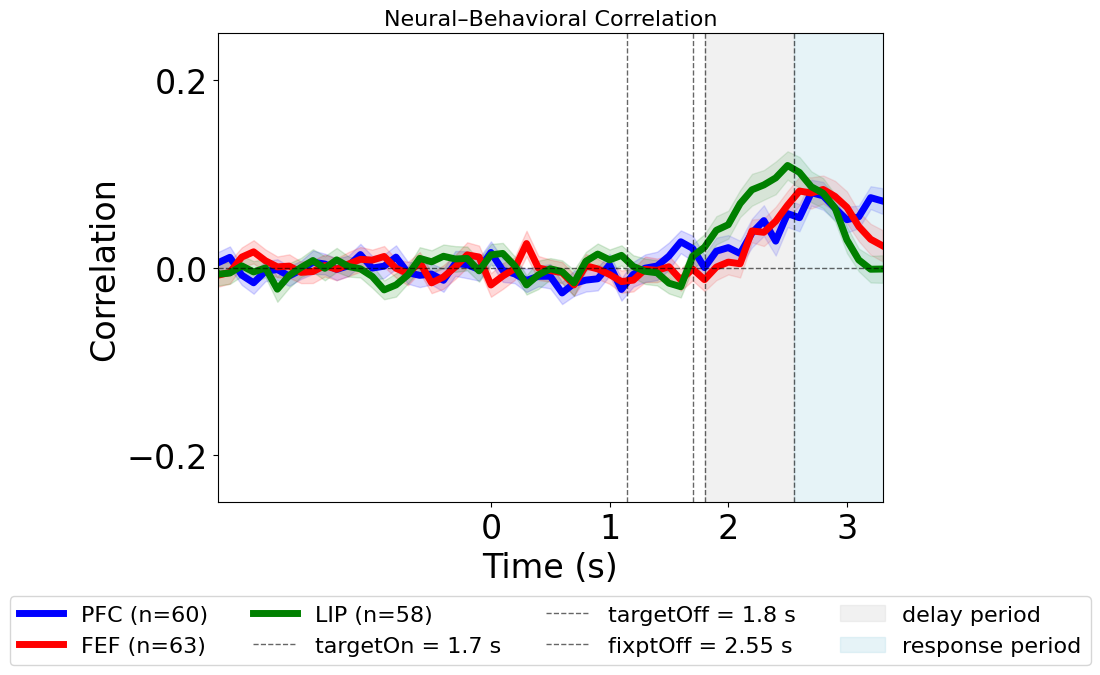

In [32]:
# Compute circular correlation per region, session, and time
regions = ['PFC', 'FEF', 'LIP']
# regions = ['Parietal', 'IT', 'MT', 'V4']
# regions = ['Parietal', 'IT', 'MT', 'V4', 'PFC', 'FEF', 'LIP']
area_colors = {'PFC':'b','FEF':'r','LIP':'g','Parietal':'y','IT':'c','MT':'m','V4':'orange'}

plt.figure(figsize=(10, 7))

for region in regions:
    df_region = df_merged[df_merged['area'] == region]
    times = np.sort(df_region['time'].unique())
    sessions = df_region['session_id'].dropna().unique()

    r_sessions = np.full((len(sessions), len(times)), np.nan)

    for s_idx, session in enumerate(sessions):
        df_s = df_region[df_region['session_id'] == session]

        for t_idx, t in enumerate(times):
            sub = df_s[np.isclose(df_s['time'], t)]

            if len(sub) > 10:
                neural = np.radians(sub['error_deg'].values)
                behav  = np.radians(sub['err'].values)
                r_sessions[s_idx, t_idx] = circ_corr(neural, behav)

    r_mean = np.nanmean(r_sessions, axis=0)
    r_sem  = np.nanstd(r_sessions, axis=0) / np.sqrt(np.sum(~np.isnan(r_sessions), axis=0))

    color = area_colors.get(region, 'black')
    plt.plot(times, r_mean, linewidth=5, label=f'{region} (n={len(sessions)})', color=color)
    plt.fill_between(times, r_mean - r_sem, r_mean + r_sem, alpha=0.15, color=color)

plt.axhline(0, linestyle='--', color='k', alpha=0.6, linewidth=1)

# plt.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.15, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.2, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.35, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.4, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.55, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.6, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.75, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.8, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.95, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(1, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
plt.axvline(1.15, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

plt.axvline(1.7, linestyle='--', color='k', alpha=0.6, label='targetOn = 1.7 s', linewidth=1)
plt.axvline(1.8, linestyle='--', color='k', alpha=0.6, label='targetOff = 1.8 s', linewidth=1)
plt.axvline(2.55, linestyle='--', color='k', alpha=0.6, label='fixptOff = 2.55 s', linewidth=1)
plt.axvspan(1.8, 2.55, color='lightgray', alpha=0.3, label='delay period')
plt.axvspan(2.55, 3.5, color='lightblue', alpha=0.3, label='response period')

plt.xlabel('Time (s)', fontsize=24)
plt.ylabel('Correlation', fontsize=24)
plt.title('Neural–Behavioral Correlation', fontsize=16)
plt.xticks([0, 1, 2, 3], fontsize=24)
plt.yticks([-0.2, 0, 0.2], fontsize=24)
plt.xlim(-2.3, 3.3)
plt.ylim(-0.25, 0.25)
plt.legend(fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, borderaxespad=0)
plt.tight_layout()
plt.show()


PFC (n=60): Delay=0.0277±0.0099, Response=0.0657±0.0098
FEF (n=63): Delay=0.0212±0.0097, Response=0.0605±0.0129
LIP (n=58): Delay=0.0628±0.0118, Response=0.0459±0.0099
Parietal (n=23): Delay=0.0126±0.0145, Response=0.0313±0.0074
IT (n=13): Delay=0.0236±0.0158, Response=0.0091±0.0179
MT (n=22): Delay=-0.0398±0.0190, Response=0.0030±0.0167
V4 (n=27): Delay=-0.0069±0.0109, Response=-0.0575±0.0163


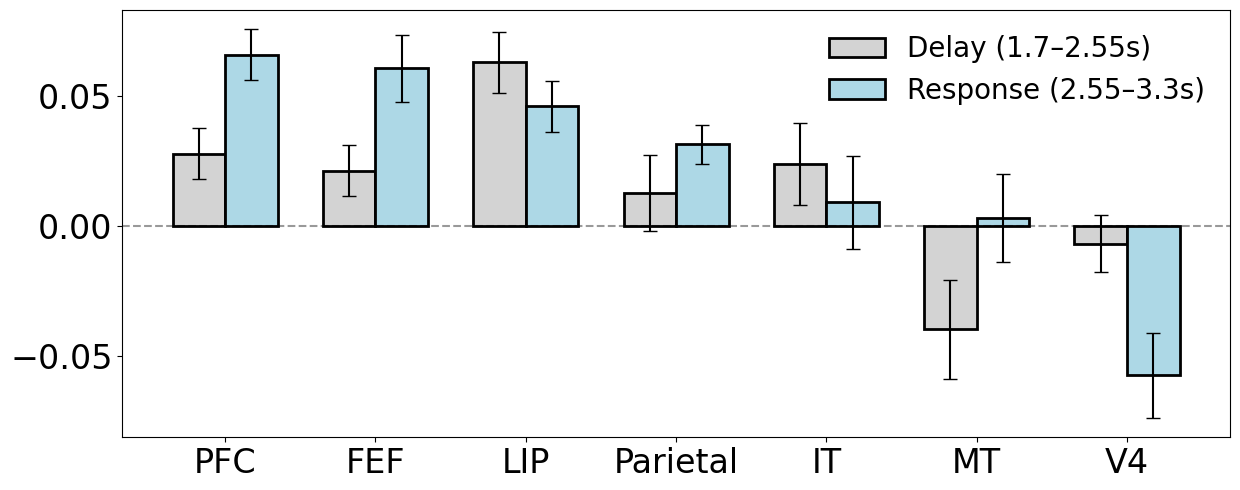

In [33]:


regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']
# area_colors = {'PFC':'b','FEF':'r','LIP':'g','Parietal':'y','IT':'c','MT':'m','V4':'orange'}
area_colors = {'PFC':'k','FEF':'k','LIP':'k','Parietal':'k','IT':'k','MT':'k','V4':'k'}

n_regions = len(regions)
fig, ax = plt.subplots(figsize=(n_regions * 1.5 + 2, 5))

x = np.arange(n_regions)
bar_width = 0.35

delay_means, delay_sems = [], []
response_means, response_sems = [], []

for region in regions:
    df_region = df_merged[df_merged['area'] == region]
    times = np.sort(df_region['time'].unique())
    sessions = df_region['session_id'].dropna().unique()

    r_sessions = np.full((len(sessions), len(times)), np.nan)

    for s_idx, session in enumerate(sessions):
        df_s = df_region[df_region['session_id'] == session]
        for t_idx, t in enumerate(times):
            sub = df_s[np.isclose(df_s['time'], t)]
            if len(sub) > 10:
                neural = np.radians(sub['error_deg'].values)
                behav  = np.radians(sub['err'].values)
                r_sessions[s_idx, t_idx] = circ_corr(neural, behav)

    # Define delay and response masks
    delay_mask = (times >= 1.7) & (times < 2.55)
    response_mask = (times >= 2.55) & (times <= 3.3)

    # Average correlation across time bins per session, then across sessions
    delay_per_session = np.nanmean(r_sessions[:, delay_mask], axis=1)
    response_per_session = np.nanmean(r_sessions[:, response_mask], axis=1)

    n_valid_delay = np.sum(~np.isnan(delay_per_session))
    n_valid_response = np.sum(~np.isnan(response_per_session))

    delay_means.append(np.nanmean(delay_per_session))
    delay_sems.append(np.nanstd(delay_per_session) / np.sqrt(n_valid_delay))

    response_means.append(np.nanmean(response_per_session))
    response_sems.append(np.nanstd(response_per_session) / np.sqrt(n_valid_response))

    print(f"{region} (n={len(sessions)}): Delay={delay_means[-1]:.4f}±{delay_sems[-1]:.4f}, "
          f"Response={response_means[-1]:.4f}±{response_sems[-1]:.4f}")

for i, region in enumerate(regions):
    ax.bar(x[i] - bar_width/2, delay_means[i], bar_width, yerr=delay_sems[i],
           capsize=5, color='lightgray', edgecolor=area_colors[region], linewidth=2)
    ax.bar(x[i] + bar_width/2, response_means[i], bar_width, yerr=response_sems[i],
           capsize=5, color='lightblue', edgecolor=area_colors[region], linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=20)
# ax.set_ylabel('Correlation', fontsize=24)
# ax.set_title('Neural–Behavioral Correlation: Delay vs Response', fontsize=16)
ax.axhline(0, linestyle='--', color='k', alpha=0.4)
ax.tick_params(labelsize=24)

legend_handles = [
    Patch(facecolor='lightgray', edgecolor='k', linewidth=2, label='Delay (1.7–2.55s)'),
    Patch(facecolor='lightblue', edgecolor='k', linewidth=2, label='Response (2.55–3.3s)')
]
leg = ax.legend(handles=legend_handles, fontsize=20)
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

In [34]:
delay_per_session_dict_corr = {}
response_per_session_dict = {}

for region in regions:
    df_region = df_merged[df_merged['area'] == region]
    times = np.sort(df_region['time'].unique())
    sessions = df_region['session_id'].dropna().unique()

    r_sessions = np.full((len(sessions), len(times)), np.nan)

    for s_idx, session in enumerate(sessions):
        df_s = df_region[df_region['session_id'] == session]
        for t_idx, t in enumerate(times):
            sub = df_s[np.isclose(df_s['time'], t)]
            if len(sub) > 10:
                neural = np.radians(sub['error_deg'].values)
                behav  = np.radians(sub['err'].values)
                r_sessions[s_idx, t_idx] = circ_corr(neural, behav)

    delay_mask = (times >= 1.7) & (times < 2.55)
    response_mask = (times >= 2.55) & (times <= 3.3)

    delay_per_session = np.nanmean(r_sessions[:, delay_mask], axis=1)
    response_per_session = np.nanmean(r_sessions[:, response_mask], axis=1)

    delay_per_session_dict_corr[region] = delay_per_session
    response_per_session_dict[region] = response_per_session

# Optionally print for inspection
for region, vals in delay_per_session_dict_corr.items():
    print(f"{region} delay: {vals}")


PFC delay: [-0.06956828 -0.06899816  0.00749667  0.00210135  0.10366059  0.06042332
  0.00217295  0.07459851 -0.03494809  0.13979544  0.0398892  -0.03499027
  0.05080503  0.09316216 -0.07156236 -0.01852121 -0.03532573  0.13724435
  0.0607172   0.03053859  0.03075593  0.14587616  0.022025   -0.05000848
 -0.18176098  0.03065728 -0.07793768  0.03711488 -0.05390395  0.20189174
  0.22877377 -0.02829138  0.09020585  0.00634111  0.11361099  0.0140117
  0.04814677  0.01590983  0.00879724 -0.0090354  -0.07806307 -0.09697935
 -0.02122193  0.06471799  0.01790715  0.06198969  0.15000129 -0.03384438
  0.11239539 -0.0321409   0.10156402  0.07140716  0.09685429 -0.03031956
 -0.04489334  0.08382813  0.02308215  0.02822321  0.13908854 -0.01261263]
FEF delay: [-0.00856006 -0.07442463  0.09468127  0.01193145  0.07202397  0.05105326
  0.03143537  0.02972434 -0.02518397  0.23605662  0.07342171  0.10923323
  0.08421154 -0.14124414 -0.02995277 -0.04848057  0.19113609  0.17805021
  0.02174969 -0.00143084  0.0

In [35]:
delay_per_session_dict_corr

{'PFC': array([-0.06956828, -0.06899816,  0.00749667,  0.00210135,  0.10366059,
         0.06042332,  0.00217295,  0.07459851, -0.03494809,  0.13979544,
         0.0398892 , -0.03499027,  0.05080503,  0.09316216, -0.07156236,
        -0.01852121, -0.03532573,  0.13724435,  0.0607172 ,  0.03053859,
         0.03075593,  0.14587616,  0.022025  , -0.05000848, -0.18176098,
         0.03065728, -0.07793768,  0.03711488, -0.05390395,  0.20189174,
         0.22877377, -0.02829138,  0.09020585,  0.00634111,  0.11361099,
         0.0140117 ,  0.04814677,  0.01590983,  0.00879724, -0.0090354 ,
        -0.07806307, -0.09697935, -0.02122193,  0.06471799,  0.01790715,
         0.06198969,  0.15000129, -0.03384438,  0.11239539, -0.0321409 ,
         0.10156402,  0.07140716,  0.09685429, -0.03031956, -0.04489334,
         0.08382813,  0.02308215,  0.02822321,  0.13908854, -0.01261263]),
 'FEF': array([-0.00856006, -0.07442463,  0.09468127,  0.01193145,  0.07202397,
         0.05105326,  0.03143537,  

# FIT Linreg 

In [36]:
from scipy.stats import linregress

regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']

slopes_records = []

for region in regions:
    df_region = df_merged[df_merged['area'] == region]
    times = np.sort(df_region['time'].unique())
    sessions = df_region['session_id'].dropna().unique()

    delay_mask = (times >= 1.7) & (times < 2.55)
    response_mask = (times >= 2.55) & (times <= 3.3)

    for session in sessions:
        df_s = df_region[df_region['session_id'] == session]

        r_values = np.full(len(times), np.nan)
        for t_idx, t in enumerate(times):
            sub = df_s[np.isclose(df_s['time'], t)]
            if len(sub) > 10:
                neural = np.radians(sub['error_deg'].values)
                behav  = np.radians(sub['err'].values)
                r_values[t_idx] = circ_corr(neural, behav)

        # Delay slope
        r_delay = r_values[delay_mask]
        t_delay = times[delay_mask]
        valid_d = ~np.isnan(r_delay)
        if valid_d.sum() > 2:
            slope_d, _, _, pval_d, _ = linregress(t_delay[valid_d], r_delay[valid_d])
        else:
            slope_d, pval_d = np.nan, np.nan

        # Response slope
        r_resp = r_values[response_mask]
        t_resp = times[response_mask]
        valid_r = ~np.isnan(r_resp)
        if valid_r.sum() > 2:
            slope_r, _, _, pval_r, _ = linregress(t_resp[valid_r], r_resp[valid_r])
        else:
            slope_r, pval_r = np.nan, np.nan

        slopes_records.append({
            'area': region,
            'session': int(session),
            'delay_slope': slope_d,
            'delay_pval': pval_d,
            'response_slope': slope_r,
            'response_pval': pval_r,
        })

df_slopes = pd.DataFrame(slopes_records)

# Summary per region
summary = df_slopes.groupby('area').agg(
    n_sessions=('session', 'count'),
    delay_slope_mean=('delay_slope', 'mean'),
    delay_slope_sem=('delay_slope', lambda x: x.std() / np.sqrt(x.notna().sum())),
    response_slope_mean=('response_slope', 'mean'),
    response_slope_sem=('response_slope', lambda x: x.std() / np.sqrt(x.notna().sum())),
).loc[regions]

print(summary.to_string())
print(f"\nTotal records: {len(df_slopes)}")
df_slopes.head(10)

          n_sessions  delay_slope_mean  delay_slope_sem  response_slope_mean  response_slope_sem
area                                                                                            
PFC               60          0.052309         0.024312             0.002234            0.024403
FEF               63          0.094363         0.023779            -0.093418            0.030149
LIP               58          0.123762         0.023614            -0.167638            0.034099
Parietal          23          0.001448         0.041164            -0.060065            0.040856
IT                13          0.083917         0.050601            -0.158390            0.082752
MT                22          0.076546         0.035409             0.007991            0.047123
V4                27          0.015885         0.033042            -0.177973            0.048775

Total records: 266


,area,session,delay_slope,delay_pval,response_slope,response_pval
0,PFC,100725,0.209973,0.028575,0.326329,0.004548
1,PFC,100731,-0.088190,0.330361,0.467479,0.000218
2,PFC,100730,0.136607,0.050073,0.272761,0.059953
3,PFC,100724,0.275968,0.006873,-0.148707,0.092623
4,PFC,100917,0.183784,0.069104,0.056351,0.416715
5,PFC,100915,0.343830,0.000122,-0.006225,0.930568
6,PFC,100726,-0.041967,0.345788,-0.384813,0.019234
7,PFC,101202,0.344367,0.010279,-0.100176,0.358698
8,PFC,101216,0.360961,0.001674,-0.030884,0.837527
9,PFC,101028,0.230699,0.005833,0.076079,0.234774


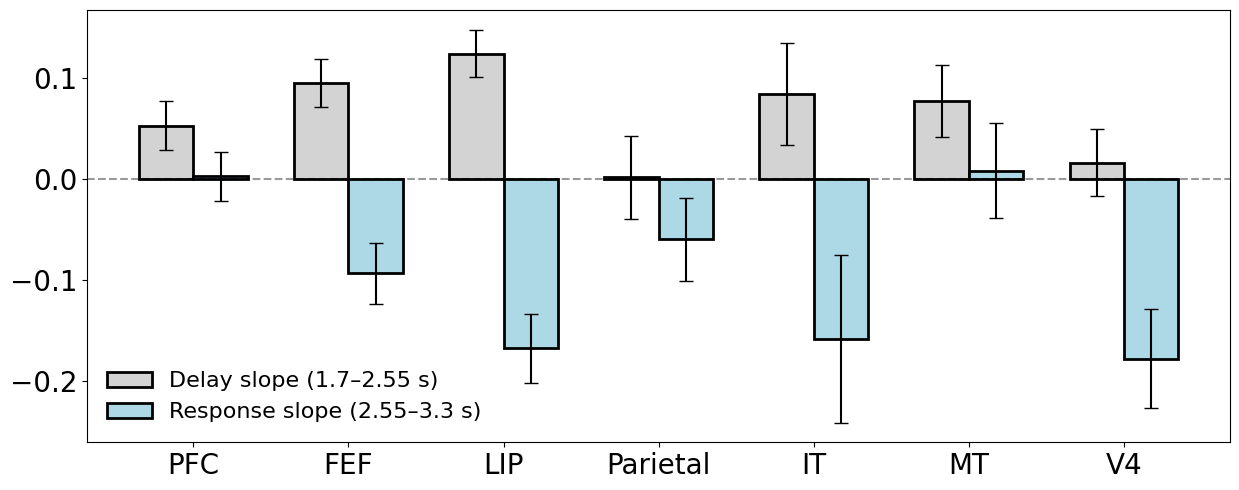

In [37]:
regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']

n_regions = len(regions)
fig, ax = plt.subplots(figsize=(n_regions * 1.5 + 2, 5))

x = np.arange(n_regions)
bar_width = 0.35

delay_means = summary['delay_slope_mean'].values
delay_sems = summary['delay_slope_sem'].values
response_means = summary['response_slope_mean'].values
response_sems = summary['response_slope_sem'].values

for i, region in enumerate(regions):
    ax.bar(x[i] - bar_width/2, delay_means[i], bar_width, yerr=delay_sems[i],
           capsize=5, color='lightgray', edgecolor='k', linewidth=2)
    ax.bar(x[i] + bar_width/2, response_means[i], bar_width, yerr=response_sems[i],
           capsize=5, color='lightblue', edgecolor='k', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=20)
# ax.set_ylabel('Slope (corr / s)', fontsize=20)
ax.axhline(0, linestyle='--', color='k', alpha=0.4)
ax.tick_params(labelsize=20)

legend_handles = [
    Patch(facecolor='lightgray', edgecolor='k', linewidth=2, label='Delay slope (1.7–2.55 s)'),
    Patch(facecolor='lightblue', edgecolor='k', linewidth=2, label='Response slope (2.55–3.3 s)')
]
leg = ax.legend(handles=legend_handles, fontsize=16)
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

# DECODING

In [38]:
with open('/home/aarghavan/aslan/delsac-neural-decoding/results/per_session_circcorr.pkl', 'rb') as f:
    data = pickle.load(f)

In [39]:
print(data.keys()   )
print(data['PFC'].keys())
print(data['PFC'][0].keys())
print(len(data['PFC'][0]['targetAngle']))


dict_keys(['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4'])
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62])
dict_keys(['targetAngle'])
58


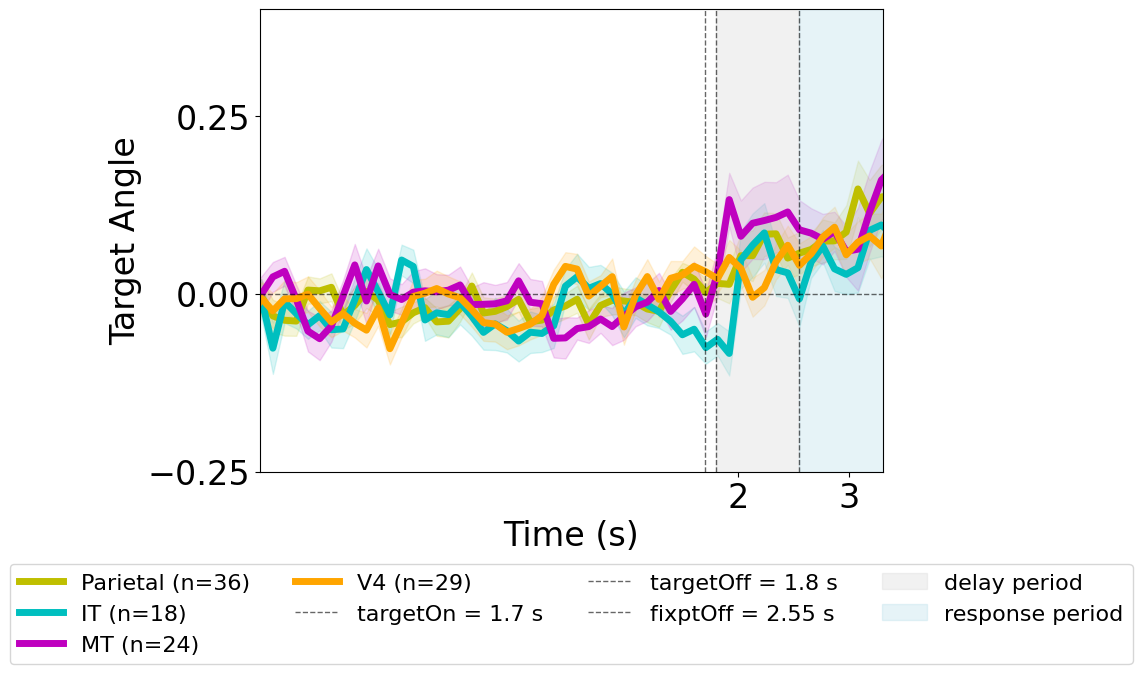

In [40]:
regions = ['Parietal', 'IT', 'MT', 'V4']
# regions = ['PFC', 'FEF', 'LIP']
area_colors = {'PFC':'b','FEF':'r','LIP':'g','Parietal':'y','IT':'c','MT':'m','V4':'orange'}

plt.figure(figsize=(10, 7))

for region in regions:
    session_keys = list(data[region].keys())
    n_sessions = len(session_keys)
    all_sessions = np.array([data[region][s]['targetAngle'] for s in session_keys])
    
    mean_ts = np.nanmean(all_sessions, axis=0)
    sem_ts = np.nanstd(all_sessions, axis=0) / np.sqrt(n_sessions)
    
    n_bins = len(mean_ts)
    time_sec = np.linspace(-2.5, 3.5, n_bins)
    
    plt.plot(time_sec, mean_ts, linewidth=5, label=f'{region} (n={n_sessions})',
             color=area_colors.get(region, 'black'))
    plt.fill_between(time_sec, mean_ts - sem_ts, mean_ts + sem_ts, alpha=0.15,
                     color=area_colors.get(region, 'black'))

plt.axhline(0, linestyle='--', color='k', alpha=0.6, linewidth=1)

# plt.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.15, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.2, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.35, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.4, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.55, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.6, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.75, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.8, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.95, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(1, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(1.15, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

plt.axvline(1.7, linestyle='--', color='k', alpha=0.6, label='targetOn = 1.7 s', linewidth=1) #targetOn

plt.axvline(1.8, linestyle='--', color='k', alpha=0.6, label='targetOff = 1.8 s', linewidth=1)#targetOff

plt.axvline(2.55, linestyle='--', color='k', alpha=0.6, label='fixptOff = 2.55 s', linewidth=1)

plt.axvspan(1.8, 2.55, color='lightgray', alpha=0.3, label='delay period')
plt.axvspan(2.55, 3.5, color='lightblue', alpha=0.3, label='response period')

plt.xlabel('Time (s)', fontsize=24)
plt.ylabel('Target Angle', fontsize=24)
plt.xticks([ 2, 3], fontsize=24)
plt.yticks([-0.25, 0, 0.25, 0.5], fontsize=24)
plt.xlim(-2.3, 3.3)
plt.ylim(-0.25, 0.4)
plt.legend(fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, borderaxespad=0)
plt.tight_layout()
plt.show()

PFC (n=63): Delay=0.0332±0.0230, Response=0.0716±0.0343
FEF (n=63): Delay=0.0895±0.0263, Response=0.1118±0.0388
LIP (n=61): Delay=0.1073±0.0354, Response=0.1565±0.0364
Parietal (n=36): Delay=0.0573±0.0212, Response=0.1119±0.0255
IT (n=18): Delay=0.0274±0.0235, Response=0.0688±0.0223
MT (n=24): Delay=0.1017±0.0373, Response=0.1208±0.0302
V4 (n=29): Delay=0.0375±0.0161, Response=0.0814±0.0174


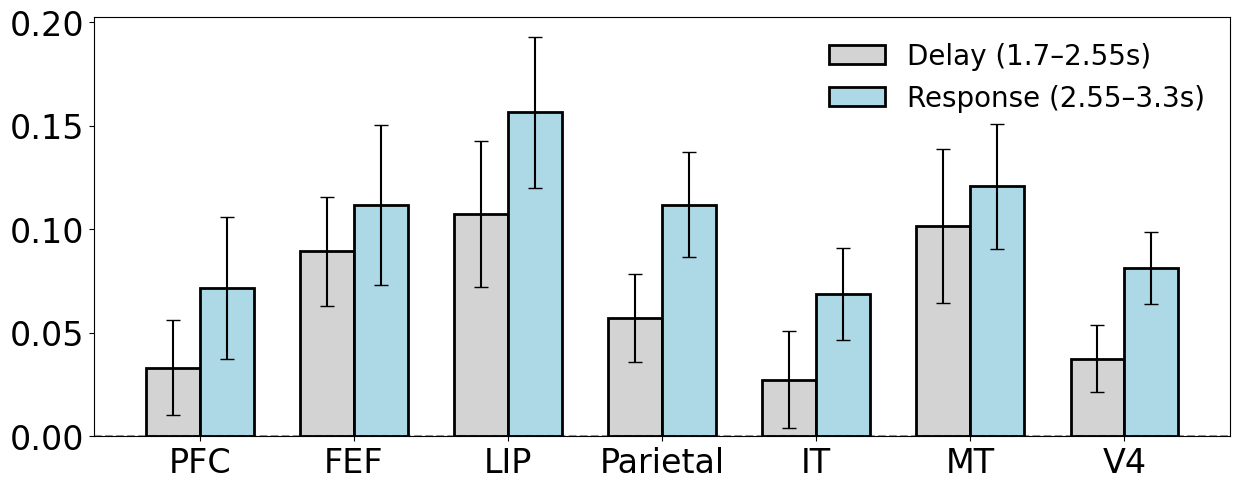

In [41]:
regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']
# area_colors = {'PFC':'b','FEF':'r','LIP':'g','Parietal':'y','IT':'c','MT':'m','V4':'orange'}
area_colors = {'PFC':'k','FEF':'k','LIP':'k','Parietal':'k','IT':'k','MT':'k','V4':'k'}

n_regions = len(regions)
fig, ax = plt.subplots(figsize=(n_regions * 1.5 + 2, 5))

x = np.arange(n_regions)
bar_width = 0.35

delay_means, delay_sems = [], []
response_means, response_sems = [], []

for region in regions:
    session_keys = list(data[region].keys())
    n_sessions = len(session_keys)
    all_sessions = np.array([data[region][s]['targetAngle'] for s in session_keys])

    n_bins = all_sessions.shape[1]
    time_sec = np.linspace(-2.5, 3.3, n_bins)

    delay_mask = (time_sec >= 1.7) & (time_sec < 2.55)
    response_mask = (time_sec >= 2.55) & (time_sec <= 3.3)

    delay_per_session = np.nanmean(all_sessions[:, delay_mask], axis=1)
    response_per_session = np.nanmean(all_sessions[:, response_mask], axis=1)

    delay_means.append(np.nanmean(delay_per_session))
    delay_sems.append(np.nanstd(delay_per_session) / np.sqrt(n_sessions))

    response_means.append(np.nanmean(response_per_session))
    response_sems.append(np.nanstd(response_per_session) / np.sqrt(n_sessions))

    print(f"{region} (n={n_sessions}): Delay={delay_means[-1]:.4f}±{delay_sems[-1]:.4f}, "
          f"Response={response_means[-1]:.4f}±{response_sems[-1]:.4f}")

for i, region in enumerate(regions):
    ax.bar(x[i] - bar_width/2, delay_means[i], bar_width, yerr=delay_sems[i],
           capsize=5, color='lightgray', edgecolor=area_colors[region], linewidth=2)
    ax.bar(x[i] + bar_width/2, response_means[i], bar_width, yerr=response_sems[i],
           capsize=5, color='lightblue', edgecolor=area_colors[region], linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=20)
ax.axhline(0, linestyle='--', color='k', alpha=0.4)
ax.tick_params(labelsize=24)

# Manual legend with neutral edge colors
legend_handles = [
    Patch(facecolor='lightgray', edgecolor='k', linewidth=2, label='Delay (1.7–2.55s)'),
    Patch(facecolor='lightblue', edgecolor='k', linewidth=2, label='Response (2.55–3.3s)')
]
leg = ax.legend(handles=legend_handles, fontsize=20)
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

In [42]:
delay_per_session_dict_decoding = {}

for region in regions:
    session_keys = list(data[region].keys())
    n_sessions = len(session_keys)
    all_sessions = np.array([data[region][s]['targetAngle'] for s in session_keys])

    n_bins = all_sessions.shape[1]
    time_sec = np.linspace(-2.5, 3.3, n_bins)

    delay_mask = (time_sec >= 1.7) & (time_sec < 2.55)
    delay_per_session = np.nanmean(all_sessions[:, delay_mask], axis=1)

    delay_per_session_dict_decoding[region] = delay_per_session

# Optionally, print or inspect
for region, vals in delay_per_session_dict_decoding.items():
    print(f"{region}: {vals}")

PFC: [-2.85205699e-02 -1.66851165e-01  5.06664766e-05 -3.58140048e-02
  4.42757668e-02 -4.02509134e-01  3.01755657e-01  5.23583489e-02
 -4.90700951e-02  1.60939953e-01 -3.46189862e-01 -7.78620186e-02
  1.60861802e-01  4.39736210e-01  9.03940903e-02  5.12850169e-03
  1.98817087e-01 -2.20195957e-01 -5.20449692e-02 -5.14750800e-02
  2.09577778e-01  2.63189778e-02  9.89335714e-02  4.03094712e-01
 -2.31249270e-02 -2.83991538e-01 -6.68267040e-02  1.59662431e-01
  1.63343105e-01  6.55839068e-02 -4.90187483e-02  6.17507112e-02
 -7.66685849e-02  1.20226725e-02  1.70065836e-01  2.72201082e-01
  1.49616432e-01 -2.19953423e-02 -8.44160695e-02  2.72091918e-01
 -1.49859960e-01  1.21888693e-01 -8.47444940e-02  1.49147796e-01
  3.05972448e-01  1.19140879e-01  1.45326100e-01  1.50760287e-01
 -8.56161754e-03 -2.06299957e-01 -3.17993889e-01 -1.09604759e-01
  8.39275394e-04  2.42017895e-03 -1.79703309e-02 -6.32135055e-02
  6.04679544e-02 -5.21279442e-02  1.18327615e-01 -3.98714488e-01
  3.72986693e-01  1.

In [43]:
delay_per_session_dict_decoding

{'PFC': array([-2.85205699e-02, -1.66851165e-01,  5.06664766e-05, -3.58140048e-02,
         4.42757668e-02, -4.02509134e-01,  3.01755657e-01,  5.23583489e-02,
        -4.90700951e-02,  1.60939953e-01, -3.46189862e-01, -7.78620186e-02,
         1.60861802e-01,  4.39736210e-01,  9.03940903e-02,  5.12850169e-03,
         1.98817087e-01, -2.20195957e-01, -5.20449692e-02, -5.14750800e-02,
         2.09577778e-01,  2.63189778e-02,  9.89335714e-02,  4.03094712e-01,
        -2.31249270e-02, -2.83991538e-01, -6.68267040e-02,  1.59662431e-01,
         1.63343105e-01,  6.55839068e-02, -4.90187483e-02,  6.17507112e-02,
        -7.66685849e-02,  1.20226725e-02,  1.70065836e-01,  2.72201082e-01,
         1.49616432e-01, -2.19953423e-02, -8.44160695e-02,  2.72091918e-01,
        -1.49859960e-01,  1.21888693e-01, -8.47444940e-02,  1.49147796e-01,
         3.05972448e-01,  1.19140879e-01,  1.45326100e-01,  1.50760287e-01,
        -8.56161754e-03, -2.06299957e-01, -3.17993889e-01, -1.09604759e-01,
     

In [44]:
from scipy.stats import linregress

regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']

decoding_slopes_records = []

for region in regions:
    session_keys = list(data[region].keys())

    for s in session_keys:
        ts = np.array(data[region][s]['targetAngle'])
        n_bins = len(ts)
        time_sec = np.linspace(-2.5, 3.3, n_bins)

        delay_mask = (time_sec >= 1.7) & (time_sec < 2.55)
        response_mask = (time_sec >= 2.55) & (time_sec <= 3.3)

        # Delay slope
        t_delay = time_sec[delay_mask]
        r_delay = ts[delay_mask]
        valid_d = ~np.isnan(r_delay)
        if valid_d.sum() > 2:
            slope_d, _, _, pval_d, _ = linregress(t_delay[valid_d], r_delay[valid_d])
        else:
            slope_d, pval_d = np.nan, np.nan

        # Response slope
        t_resp = time_sec[response_mask]
        r_resp = ts[response_mask]
        valid_r = ~np.isnan(r_resp)
        if valid_r.sum() > 2:
            slope_r, _, _, pval_r, _ = linregress(t_resp[valid_r], r_resp[valid_r])
        else:
            slope_r, pval_r = np.nan, np.nan

        decoding_slopes_records.append({
            'area': region,
            'session': s,
            'delay_slope': slope_d,
            'delay_pval': pval_d,
            'response_slope': slope_r,
            'response_pval': pval_r,
        })

df_decoding_slopes = pd.DataFrame(decoding_slopes_records)

decoding_summary = df_decoding_slopes.groupby('area').agg(
    n_sessions=('session', 'count'),
    delay_slope_mean=('delay_slope', 'mean'),
    delay_slope_sem=('delay_slope', lambda x: x.std() / np.sqrt(x.notna().sum())),
    response_slope_mean=('response_slope', 'mean'),
    response_slope_sem=('response_slope', lambda x: x.std() / np.sqrt(x.notna().sum())),
).loc[regions]

print(decoding_summary.to_string())
print(f"\nTotal records: {len(df_decoding_slopes)}")

          n_sessions  delay_slope_mean  delay_slope_sem  response_slope_mean  response_slope_sem
area                                                                                            
PFC               63          0.010448         0.073739             0.160843            0.084459
FEF               63          0.034710         0.062446            -0.005117            0.106556
LIP               61         -0.053583         0.071247             0.284025            0.111807
Parietal          36          0.041112         0.039207             0.092245            0.078249
IT                18          0.053377         0.080286             0.097878            0.057751
MT                24         -0.027196         0.051301             0.217323            0.105319
V4                29          0.036642         0.056419             0.025244            0.087434

Total records: 294


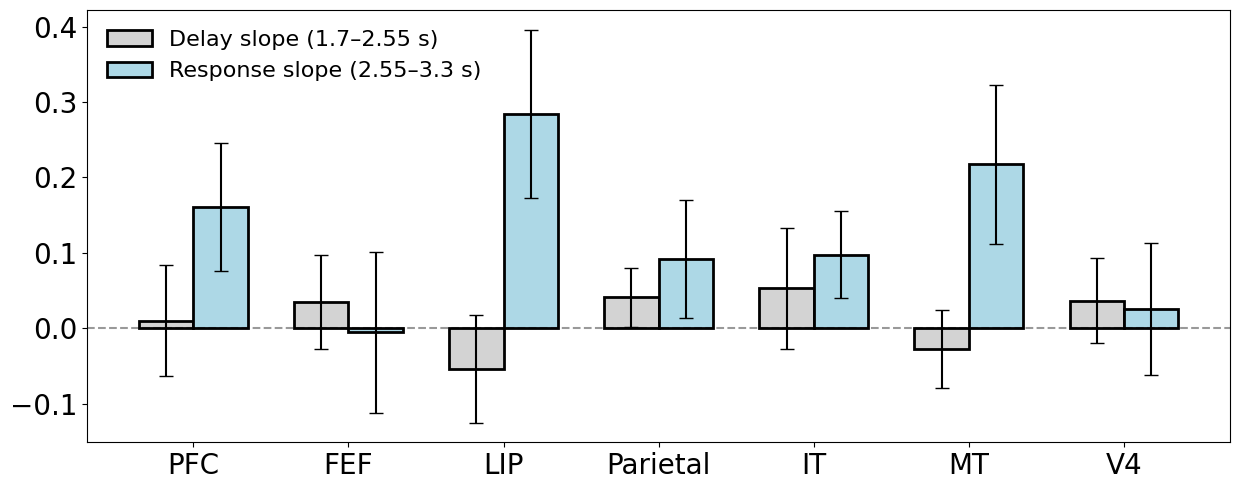

In [45]:
regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']

n_regions = len(regions)
fig, ax = plt.subplots(figsize=(n_regions * 1.5 + 2, 5))

x = np.arange(n_regions)
bar_width = 0.35

delay_means = decoding_summary['delay_slope_mean'].values
delay_sems = decoding_summary['delay_slope_sem'].values
response_means = decoding_summary['response_slope_mean'].values
response_sems = decoding_summary['response_slope_sem'].values

for i, region in enumerate(regions):
    ax.bar(x[i] - bar_width/2, delay_means[i], bar_width, yerr=delay_sems[i],
           capsize=5, color='lightgray', edgecolor='k', linewidth=2)
    ax.bar(x[i] + bar_width/2, response_means[i], bar_width, yerr=response_sems[i],
           capsize=5, color='lightblue', edgecolor='k', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=20)
# ax.set_ylabel('Slope (decoding / s)', fontsize=20)
ax.axhline(0, linestyle='--', color='k', alpha=0.4)
ax.tick_params(labelsize=20)

legend_handles = [
    Patch(facecolor='lightgray', edgecolor='k', linewidth=2, label='Delay slope (1.7–2.55 s)'),
    Patch(facecolor='lightblue', edgecolor='k', linewidth=2, label='Response slope (2.55–3.3 s)')
]
leg = ax.legend(handles=legend_handles, fontsize=16)
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

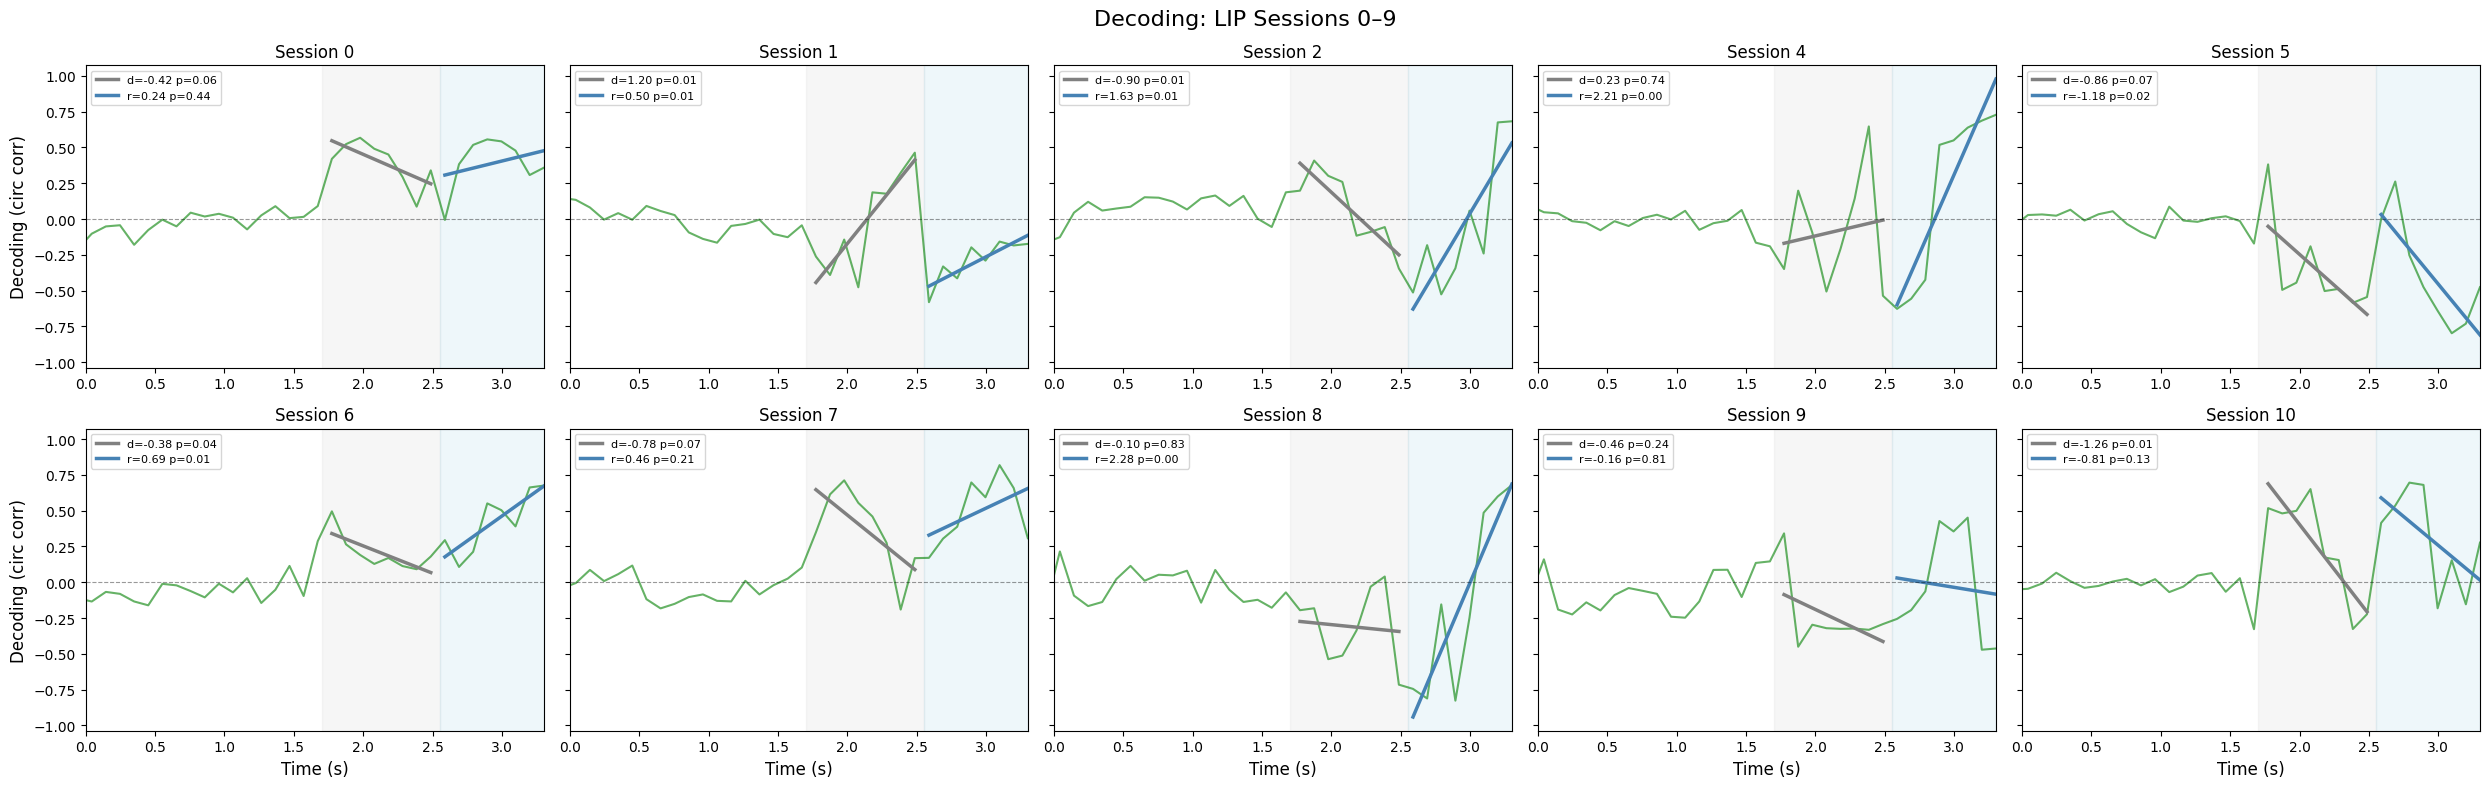

In [46]:
from scipy.stats import linregress

region = 'LIP'
session_keys = list(data[region].keys())[:10]

fig, axes = plt.subplots(2, 5, figsize=(25, 8), sharey=True)
axes = axes.flatten()

for i, s_key in enumerate(session_keys):
    ax = axes[i]
    
    ts = np.array(data[region][s_key]['targetAngle'])
    n_bins = len(ts)
    time_sec = np.linspace(-2.5, 3.3, n_bins)

    delay_mask = (time_sec >= 1.7) & (time_sec < 2.55)
    response_mask = (time_sec >= 2.55) & (time_sec <= 3.3)

    # Fit linreg
    valid_d = ~np.isnan(ts[delay_mask])
    slope_d, intercept_d, _, pval_d, _ = linregress(time_sec[delay_mask][valid_d], ts[delay_mask][valid_d])

    valid_r = ~np.isnan(ts[response_mask])
    slope_r, intercept_r, _, pval_r, _ = linregress(time_sec[response_mask][valid_r], ts[response_mask][valid_r])

    ax.plot(time_sec, ts, linewidth=1.5, color='g', alpha=0.6)
    ax.plot(time_sec[delay_mask], slope_d * time_sec[delay_mask] + intercept_d,
            linewidth=2.5, color='gray', label=f'd={slope_d:.2f} p={pval_d:.2f}')
    ax.plot(time_sec[response_mask], slope_r * time_sec[response_mask] + intercept_r,
            linewidth=2.5, color='steelblue', label=f'r={slope_r:.2f} p={pval_r:.2f}')

    ax.axhline(0, linestyle='--', color='k', alpha=0.4, linewidth=0.8)
    ax.axvspan(1.7, 2.55, color='lightgray', alpha=0.2)
    ax.axvspan(2.55, 3.3, color='lightblue', alpha=0.2)
    ax.set_xlim(0, 3.3)
    ax.set_title(f'Session {s_key}', fontsize=12)
    ax.legend(fontsize=8, loc='upper left')

    if i >= 5:
        ax.set_xlabel('Time (s)', fontsize=12)
    if i % 5 == 0:
        ax.set_ylabel('Decoding (circ corr)', fontsize=12)

fig.suptitle(f'Decoding: LIP Sessions 0–9', fontsize=16)
plt.tight_layout()
plt.show()

In [47]:
# Demean per region for both dicts
demeaned_corr = {}
demeaned_decoding = {}

for region in regions:
    vals_corr = delay_per_session_dict_corr[region]
    vals_decoding = delay_per_session_dict_decoding[region]
    demeaned_corr[region] = vals_corr - np.nanmean(vals_corr)
    demeaned_decoding[region] = vals_decoding - np.nanmean(vals_decoding)

# Optionally print to check
for region in regions:
    print(f"{region} demeaned corr: {demeaned_corr[region]}")
    print(f"{region} demeaned decoding: {demeaned_decoding[region]}")

PFC demeaned corr: [-0.09728254 -0.09671241 -0.02021758 -0.02561291  0.07594633  0.03270906
 -0.0255413   0.04688425 -0.06266234  0.11208119  0.01217494 -0.06270453
  0.02309077  0.06544791 -0.09927662 -0.04623547 -0.06303999  0.10953009
  0.03300295  0.00282433  0.00304168  0.11816191 -0.00568926 -0.07772274
 -0.20947524  0.00294302 -0.10565194  0.00940062 -0.08161821  0.17417748
  0.20105951 -0.05600564  0.06249159 -0.02137315  0.08589674 -0.01370255
  0.02043251 -0.01180443 -0.01891701 -0.03674966 -0.10577733 -0.12469361
 -0.04893618  0.03700373 -0.00980711  0.03427544  0.12228703 -0.06155864
  0.08468113 -0.05985516  0.07384976  0.0436929   0.06914003 -0.05803382
 -0.0726076   0.05611387 -0.0046321   0.00050895  0.11137428 -0.04032689]
PFC demeaned decoding: [-0.06174376 -0.20007435 -0.03317252 -0.06903719  0.01105258 -0.43573232
  0.26853247  0.01913516 -0.08229328  0.12771676 -0.37941305 -0.11108521
  0.12763861  0.40651302  0.0571709  -0.02809469  0.1655939  -0.25341915
 -0.0852

In [48]:
delay_per_session_dict_corr

{'PFC': array([-0.06956828, -0.06899816,  0.00749667,  0.00210135,  0.10366059,
         0.06042332,  0.00217295,  0.07459851, -0.03494809,  0.13979544,
         0.0398892 , -0.03499027,  0.05080503,  0.09316216, -0.07156236,
        -0.01852121, -0.03532573,  0.13724435,  0.0607172 ,  0.03053859,
         0.03075593,  0.14587616,  0.022025  , -0.05000848, -0.18176098,
         0.03065728, -0.07793768,  0.03711488, -0.05390395,  0.20189174,
         0.22877377, -0.02829138,  0.09020585,  0.00634111,  0.11361099,
         0.0140117 ,  0.04814677,  0.01590983,  0.00879724, -0.0090354 ,
        -0.07806307, -0.09697935, -0.02122193,  0.06471799,  0.01790715,
         0.06198969,  0.15000129, -0.03384438,  0.11239539, -0.0321409 ,
         0.10156402,  0.07140716,  0.09685429, -0.03031956, -0.04489334,
         0.08382813,  0.02308215,  0.02822321,  0.13908854, -0.01261263]),
 'FEF': array([-0.00856006, -0.07442463,  0.09468127,  0.01193145,  0.07202397,
         0.05105326,  0.03143537,  

In [49]:
delay_per_session_dict_decoding

{'PFC': array([-2.85205699e-02, -1.66851165e-01,  5.06664766e-05, -3.58140048e-02,
         4.42757668e-02, -4.02509134e-01,  3.01755657e-01,  5.23583489e-02,
        -4.90700951e-02,  1.60939953e-01, -3.46189862e-01, -7.78620186e-02,
         1.60861802e-01,  4.39736210e-01,  9.03940903e-02,  5.12850169e-03,
         1.98817087e-01, -2.20195957e-01, -5.20449692e-02, -5.14750800e-02,
         2.09577778e-01,  2.63189778e-02,  9.89335714e-02,  4.03094712e-01,
        -2.31249270e-02, -2.83991538e-01, -6.68267040e-02,  1.59662431e-01,
         1.63343105e-01,  6.55839068e-02, -4.90187483e-02,  6.17507112e-02,
        -7.66685849e-02,  1.20226725e-02,  1.70065836e-01,  2.72201082e-01,
         1.49616432e-01, -2.19953423e-02, -8.44160695e-02,  2.72091918e-01,
        -1.49859960e-01,  1.21888693e-01, -8.47444940e-02,  1.49147796e-01,
         3.05972448e-01,  1.19140879e-01,  1.45326100e-01,  1.50760287e-01,
        -8.56161754e-03, -2.06299957e-01, -3.17993889e-01, -1.09604759e-01,
     

In [50]:
# # regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']
# regions = ['PFC']
# area_colors = {'PFC':'b','FEF':'r','LIP':'g','Parietal':'y','IT':'c','MT':'m','V4':'orange'}

# plt.figure(figsize=(8, 12))

# for region in regions:
#     x = demeaned_corr[region]
#     y = demeaned_decoding[region]
#     plt.scatter(x, y, label=region, color=area_colors[region], s=80, alpha=0.8)

# plt.xlabel('Neural-Behavioral Corr (delay, per session)', fontsize=20)
# plt.ylabel('Decoding (delay, per session)', fontsize=20)
# plt.title('Session-wise Correlation: Neural-Behavioral vs Decoding', fontsize=20)
# plt.axhline(0, color='k', linestyle='--', alpha=0.3)
# plt.axvline(0, color='k', linestyle='--', alpha=0.3)
# plt.legend(fontsize=20, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, borderaxespad=0)
# plt.xticks([-0.25, 0, 0.25], fontsize=16)
# plt.yticks([-0.5, 0, 0.5], fontsize=16)
# plt.xlim(-0.3, 0.3)
# plt.ylim(-0.9, 0.9)
# plt.tight_layout()
# plt.show()



In [51]:
print(demeaned_corr['PFC'].shape)
print(demeaned_decoding['PFC'].shape)

(60,)
(63,)


In [52]:
# from scipy.stats import pearsonr
# import numpy as np

# all_corr = np.concatenate([demeaned_corr[r] for r in regions])
# all_decoding = np.concatenate([demeaned_decoding[r] for r in regions])

# mask = ~np.isnan(all_corr) & ~np.isnan(all_decoding)
# r, p = pearsonr(all_corr[mask], all_decoding[mask])

# print(f"Pearson correlation: r = {r:.3f}, p = {p:.3g}")